# Admission Data Explorer
Exploring applicant data: gender, program preferences and admission outcomes.

**Steps:** load -> inspect -> clean -> analyze -> visualize -> insight -> export

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Load the data

In [6]:
try:
    df = pd.read_csv("data/applications.csv")
except FileNotFoundError:
    print("File not found. Run generate_mock_data.py first.")
print(df.shape)
df.head()

(1050, 8)


,applicant_id,gender,age,state_of_origin,program_applied,exam_score,high_school_gpa,admission_status
0,APP100440,Male,17.0,Niger,Computer Science,73.3,3.35,Accepted
1,APP100504,Female,17.0,Enugu,Computer Science,74.0,3.03,Accepted
2,APP100293,Male,16.0,Plateau,PUBLIC HEALTH,68.4,2.62,Accepted
3,APP100375,Male,21.0,Lagos,Computer Science,51.7,3.84,Rejected
4,APP100755,Female,16.0,Kano,Electrical Engineering,70.0,3.49,Accepted


## Data inspection and exploration
Finding exactly what makes up the dataset before it is cleaned

In [7]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate applicant IDs:", df["applicant_id"].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   applicant_id      1050 non-null   object 
 1   gender            1018 non-null   object 
 2   age               1005 non-null   float64
 3   state_of_origin   1050 non-null   object 
 4   program_applied   1050 non-null   object 
 5   exam_score        997 non-null    object 
 6   high_school_gpa   990 non-null    float64
 7   admission_status  1050 non-null   object 
dtypes: float64(2), object(6)
memory usage: 65.8+ KB

Missing values:
applicant_id         0
gender              32
age                 45
state_of_origin      0
program_applied      0
exam_score          53
high_school_gpa     60
admission_status     0
dtype: int64

Duplicate rows: 50
Duplicate applicant IDs: 50


In [8]:
print(df["gender"].unique())
print(df["program_applied"].unique())
print(df["age"].describe())

['Male' 'Female' 'female' nan 'male']
['Computer Science' 'PUBLIC HEALTH ' 'Electrical Engineering' 'NURSING '
 'Economics' 'Public Health' 'Medicine & Surgery' 'Nursing' 'Accounting'
 'Mass Communication' 'Law' 'LAW ' 'Software Engineering' 'Architecture'
 'ARCHITECTURE ' 'Microbiology' 'COMPUTER SCIENCE ' 'ACCOUNTING '
 'SOFTWARE ENGINEERING ' 'MASS COMMUNICATION ' 'MEDICINE & SURGERY '
 'ELECTRICAL ENGINEERING ' 'MICROBIOLOGY ']
count    1005.000000
mean       20.377114
std        31.410375
min        -5.000000
25%        18.000000
50%        19.000000
75%        21.000000
max       999.000000
Name: age, dtype: float64


## Data Cleaning

In [9]:
start = len(df)

# standardize text
for col in ["gender", "program_applied", "admission_status", "state_of_origin"]:
    df[col] = df[col].str.strip().str.title()
df["gender"] = df["gender"].replace({"M": "Male", "F": "Female"})

# numbers: convert, then remove impossible values
df["exam_score"] = pd.to_numeric(df["exam_score"], errors="coerce")
df.loc[~df["age"].between(14, 60), "age"] = np.nan
df.loc[~df["exam_score"].between(0, 100), "exam_score"] = np.nan

# duplicates
df = df.drop_duplicates()
df = df.drop_duplicates(subset="applicant_id", keep="last")

# fill missing values
df["age"] = df["age"].fillna(df["age"].median())
df["exam_score"] = df["exam_score"].fillna(df["exam_score"].median())
df["high_school_gpa"] = df["high_school_gpa"].fillna(df["high_school_gpa"].median())
df["gender"] = df["gender"].fillna("Unknown")
df = df.dropna(subset=["program_applied", "admission_status"])

print(f"{start} rows -> {len(df)} rows")
print(df.isnull().sum().sum(), "missing values left")

1050 rows -> 1000 rows
0 missing values left


## Data Analysis

In [11]:
decided = df[df["admission_status"] != "Pending"]
accepted = decided["admission_status"] == "Accepted"

acceptance_rate = accepted.mean() * 100
print(f"Overall acceptance rate: {acceptance_rate:.1f}%")

Overall acceptance rate: 44.9%


In [12]:
gender_share = df["gender"].value_counts(normalize=True) * 100
gender_acceptance = accepted.groupby(decided["gender"]).mean() * 100
print("Gender share (%):\n", gender_share.round(1))
print("\nAcceptance rate by gender (%):\n", gender_acceptance.round(1))

Gender share (%):
 gender
Male       51.4
Female     45.6
Unknown     3.0
Name: proportion, dtype: float64

Acceptance rate by gender (%):
 gender
Female     45.0
Male       44.5
Unknown    50.0
Name: admission_status, dtype: float64


In [13]:
top5_programs = df["program_applied"].value_counts().head(5)
top5_programs

program_applied
Computer Science        253
Software Engineering    122
Medicine & Surgery       96
Accounting               91
Law                      83
Name: count, dtype: int64

## Data Visualisation

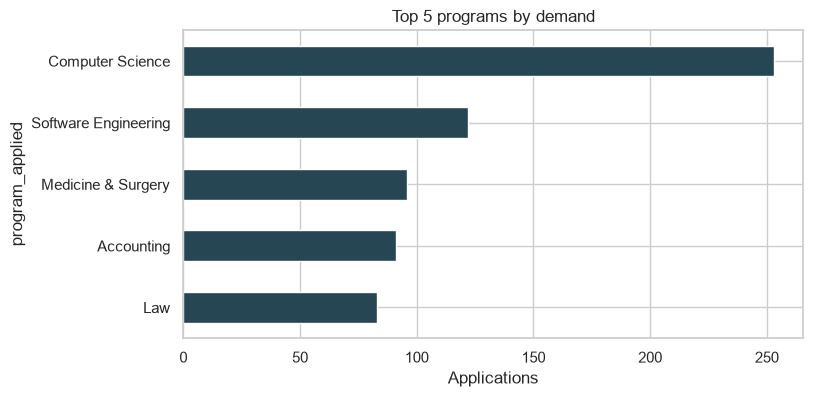

In [14]:
top5_programs.sort_values().plot(kind="barh", color="#264653", figsize=(8, 4))
plt.title("Top 5 programs by demand")
plt.xlabel("Applications")
plt.show()

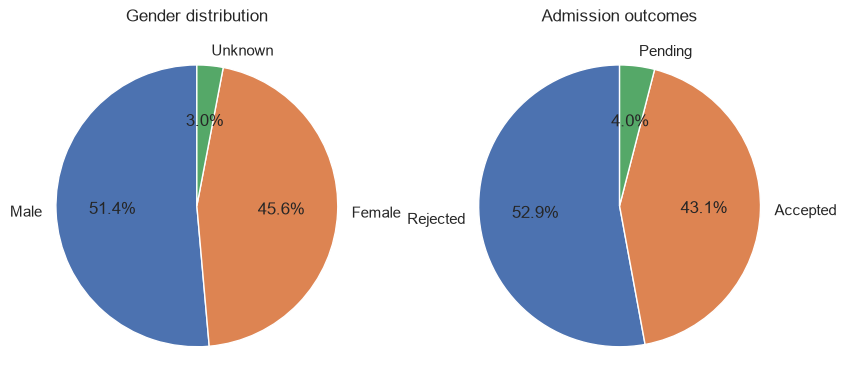

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
df["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[0], startangle=90)
axes[0].set_title("Gender distribution")
df["admission_status"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[1], startangle=90)
axes[1].set_title("Admission outcomes")
for a in axes:
    a.set_ylabel("")
plt.show()

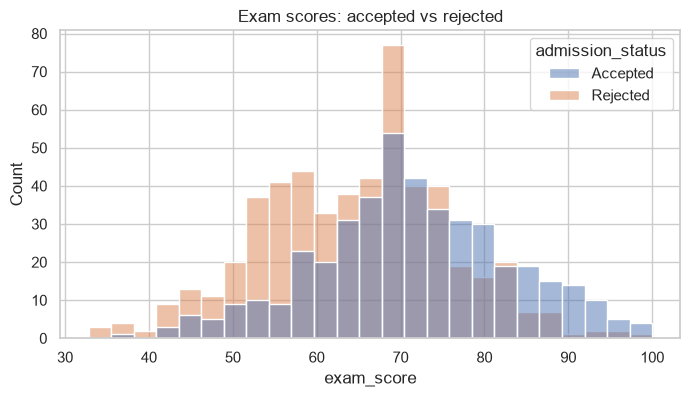

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(data=decided, x="exam_score", hue="admission_status", bins=25)
plt.title("Exam scores: accepted vs rejected")
plt.show()

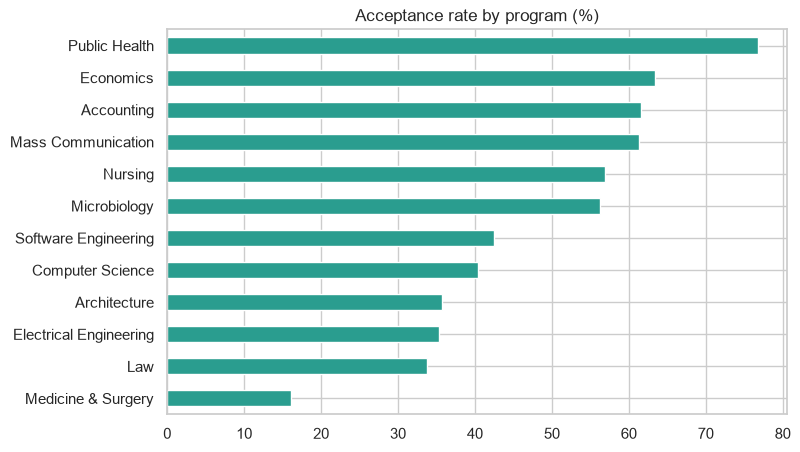

In [17]:
rates = accepted.groupby(decided["program_applied"]).mean() * 100
rates.sort_values().plot(kind="barh", color="#2a9d8f", figsize=(8, 5))
plt.title("Acceptance rate by program (%)")
plt.ylabel("")
plt.show()

## Data Insight Summary 

In [18]:
top_program = top5_programs.index[0]
female = gender_acceptance.get("Female", 0)
male = gender_acceptance.get("Male", 0)
hardest = rates.idxmin()

insight = f"Most applicants prefer {top_program}. \n"
insight += f"The overall acceptance rate is {acceptance_rate:.1f}%. \n"

if abs(female - male) < 2:
    insight += f"Acceptance is similar for both genders (female {female:.1f}%, male {male:.1f}%). \n"
elif female > male:
    insight += f"Female applicants are accepted more often ({female:.1f}% vs {male:.1f}%). \n"
else:
    insight += f"Male applicants are accepted more often ({male:.1f}% vs {female:.1f}%). \n"

insight += f"{hardest} is the most competitive program ({rates.min():.1f}% accepted)."
print(insight)

Most applicants prefer Computer Science. 
The overall acceptance rate is 44.9%. 
Acceptance is similar for both genders (female 45.0%, male 44.5%). 
Medicine & Surgery is the most competitive program (16.1% accepted).


## AI-generated summary with Google Gemini


In [ ]:
import os
import requests

key = os.getenv("GEMINI_API_KEY")
if key:
    stats = f"acceptance rate {acceptance_rate:.1f}%, top programs {top5_programs.to_dict()}, gender acceptance {gender_acceptance.round(1).to_dict()}"
    url = "https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent"
    prompt = f"Summarize these admission statistics in 3-4 plain English sentences: {stats}"
    try:
        r = requests.post(url, headers={"x-goog-api-key": key}, timeout=30,
                          json={"contents": [{"parts": [{"text": prompt}]}]})
        r.raise_for_status()
        insight = r.json()["candidates"][0]["content"]["parts"][0]["text"].strip()
    except Exception as e:
        print("AI request failed, keeping the rule-based summary:", e)
print(insight)

Most applicants prefer Computer Science. The overall acceptance rate is 44.9%. Acceptance is similar for both genders (female 45.0%, male 44.5%). Medicine & Surgery is the most competitive program (16.1% accepted).


## Export the report

In [ ]:
os.makedirs("output", exist_ok=True)

summary = pd.DataFrame({
    "metric": ["total_applicants", "pending", "acceptance_rate_pct"],
    "value": [len(df), (df["admission_status"] == "Pending").sum(), round(acceptance_rate, 1)],
})
summary.to_csv("output/notebook_summary.csv", index=False)

html = f"<h1>Admission Report</h1><p>{insight}</p>" + summary.to_html(index=False) + top5_programs.to_frame().to_html()
with open("output/notebook_summary.html", "w") as f:
    f.write(html)
print("Saved to output/")

Saved to output/


## Error handling 
The malformed file should not crash the notebook.

In [17]:
try:
    bad = pd.read_csv("data/applications_malformed.csv")
except pd.errors.ParserError:
    bad = pd.read_csv("data/applications_malformed.csv", on_bad_lines="skip", engine="python")
    print("Malformed rows skipped")

needed = ["applicant_id", "gender", "program_applied", "admission_status"]
print("Missing columns:", [c for c in needed if c not in bad.columns])

Malformed rows skipped
Missing columns: ['program_applied', 'admission_status']
